# Notebook 03: Toehold Switch Design and Thermodynamic Evaluation

## Aim
Design toehold switch RNA sequences targeting the three primary R4 candidate 
windows identified in notebook 02, evaluate their thermodynamic performance 
using ViennaRNA, and screen top designs for specificity against non-target 
organisms relevant to UK plant biosecurity field conditions.

## Biological rationale
Toehold switch sequences are designed following the second-generation design 
rules established by Green et al. (2014). The switch RNA is constructed from 
five components assembled in order from 5 prime to 3 prime: the toehold 
domain, the left stem sequence, the loop containing the ribosome binding site 
and start codon, the right stem sequence, and the linker connecting to the 
reporter gene.

The primary thermodynamic predictor of switch performance is delta G 
RBS-linker, defined as the free energy of the sequence from the RBS through 
to the end of the linker in the fully triggered switch-trigger complex. Values 
closer to zero predict higher ON/OFF ratios, as established by Green et al. 
(2014) who found R-squared = 0.79 between this parameter and measured 
ON/OFF ratios for forward-engineered switches.

## Input
- results/candidate_targets.csv from notebook 02

## Output
- results/switch_designs.csv: ranked toehold switch designs with 
  thermodynamic parameters
- results/switch_evaluation.png: thermodynamic profile plots

## 1. Setup and design parameters

In [1]:
# Standard library
import os
import sys
import itertools

# ViennaRNA for thermodynamic calculations
import RNA

# Biopython for sequence manipulation
from Bio.Seq import Seq

# Data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Set up project paths
notebook_dir = os.path.dirname(os.path.abspath("03_switch_design.ipynb"))
project_root = os.path.dirname(notebook_dir)
data_dir = os.path.join(project_root, "data")
results_dir = os.path.join(project_root, "results")

print("Project root:", project_root)
print("ViennaRNA version:", RNA.__version__)
print()

# ============================================================
# TOEHOLD SWITCH DESIGN PARAMETERS
# Following Green et al. (2014) second-generation design rules
# ============================================================

# Toehold domain length
# Reduced from recommended 24nt to 21nt to match the 30nt trigger window
# length identified in notebook 02 (toehold 21nt + left stem 9nt = 30nt).
# 21nt remains well above the 12nt minimum for synthetic triggers
# established by Green et al. (2014) and is sufficient given the high
# cross-strain accessibility scores confirmed for R4 in notebook 02.
# Extension to 24nt is recommended before experimental synthesis,
# subject to accessibility verification of the additional positions.
TOEHOLD_LENGTH = 21

# Stem length on each side of the loop
# 18nt total stem: 6bp above AUG + AUG bulge + 9bp below AUG
# Split as left_stem (before loop) and right_stem (after loop)
LEFT_STEM_LENGTH = 9   # 9bp below AUG (5' side of stem)
RIGHT_STEM_LENGTH = 9  # 9bp above AUG (3' side of stem)

# Ribosome binding site (Shine-Dalgarno sequence)
# Standard strong RBS used in E. coli cell-free systems
# as used by Pardee et al. (2016) and Green et al. (2014)
RBS = "AAGAAGGAGATA"

# Loop sequence (contains RBS and is left unpaired)
# Loop = spacer + RBS + spacer
# Total loop length ~18nt as per second-generation design
LOOP_SPACER_5 = "AA"       # 5' spacer before RBS
LOOP_SPACER_3 = "AA"       # 3' spacer after RBS

# AUG start codon
AUG = "AUG"

# Linker sequence
# Encodes low-molecular-weight amino acids (Gly-Ser repeats)
# Screened to contain no in-frame stop codons
# 21nt as specified in Green et al. (2014)
LINKER = "AACCCCTCAAGACCCGUUUGGC"

# Short lacZ fragment for thermodynamic evaluation
# First 30nt of lacZ coding sequence
# Used to calculate delta G RBS-linker in triggered complex
LACZ_START = "AUGACCAUGAUUGCCCUGACUGAAGGCG"

print("Design parameters loaded:")
print(f"  Toehold length:     {TOEHOLD_LENGTH} nt")
print(f"  Left stem length:   {LEFT_STEM_LENGTH} nt")
print(f"  Right stem length:  {RIGHT_STEM_LENGTH} nt")
print(f"  RBS sequence:       {RBS}")
print(f"  AUG:                {AUG}")
print(f"  Linker:             {LINKER} ({len(LINKER)} nt)")

Project root: /home/andre/xylella-toehold-biosensor
ViennaRNA version: 2.7.2

Design parameters loaded:
  Toehold length:     21 nt
  Left stem length:   9 nt
  Right stem length:  9 nt
  RBS sequence:       AAGAAGGAGATA
  AUG:                AUG
  Linker:             AACCCCTCAAGACCCGUUUGGC (22 nt)


## 2. Load candidate target sequences

The three primary R4 candidate target sequences confirmed as cross-strain 
accessible in notebook 02 are loaded from the candidate targets CSV. 
These sequences represent the trigger RNA that the designed switches must 
detect, i.e. the sequence present in Xylella fastidiosa 16S rRNA.

In [2]:
# Load candidate target sequences from notebook 02
targets_path = os.path.join(results_dir, "candidate_targets.csv")
targets_df = pd.read_csv(targets_path)

# Keep only primary confirmed candidates
# Note: cross_strain_confirmed was saved as string "True" not boolean
# so we filter using string comparison
primary_targets = targets_df[
    targets_df["cross_strain_confirmed"] == "True"
].copy()

print(f"Primary confirmed target sequences: {len(primary_targets)}")
print()
print(primary_targets[[
    "region_id", "window_position", "sequence",
    "pauca_accessibility", "gc_content"
]].to_string(index=False))
print()

# Display trigger sequences clearly
print("Trigger sequences (5' to 3'):")
print("-" * 50)
for _, row in primary_targets.iterrows():
    print(f"Target {row['window_position']}: {row['sequence']}")

Primary confirmed target sequences: 3

region_id window_position                       sequence  pauca_accessibility  gc_content
       R4         245-275 GUAGAGAUCAGGAGGAACAUCCGUGGCGAA               0.5393        53.3
       R4         246-276 UAGAGAUCAGGAGGAACAUCCGUGGCGAAG               0.5389        53.3
       R4         236-266 GUGAAAUGCGUAGAGAUCAGGAGGAACAUC               0.5321        46.7

Trigger sequences (5' to 3'):
--------------------------------------------------
Target 245-275: GUAGAGAUCAGGAGGAACAUCCGUGGCGAA
Target 246-276: UAGAGAUCAGGAGGAACAUCCGUGGCGAAG
Target 236-266: GUGAAAUGCGUAGAGAUCAGGAGGAACAUC


## 3. Toehold switch sequence construction

For each trigger sequence the toehold switch is assembled from its 
five components in order from 5 prime to 3 prime.

Component assembly logic:

1. Toehold domain: reverse complement of positions 1-24 of the trigger 
   sequence. This is the exposed single-stranded overhang at the 5 prime 
   end of the switch that initiates binding with the trigger RNA.

2. Left stem: reverse complement of positions 25-30 of the trigger 
   sequence (the remaining 6 positions after the toehold). Together with 
   the right stem this forms the base-paired hairpin duplex.

3. Loop: fixed sequence containing the ribosome binding site flanked by 
   short spacers. The RBS is left unpaired within the loop.

4. AUG start codon: placed at the junction between the loop and right stem. 
   In the OFF state this is partially sequestered by the stem structure.

5. Right stem: complement of the left stem (NOT reverse complement), 
   running in the 3 prime direction to complete the hairpin duplex.

6. Linker: fixed 21nt sequence encoding low molecular weight amino acids, 
   connecting the stem to the reporter gene.

Note on stop codon screening: the linker sequence is pre-screened to 
contain no in-frame stop codons (UAA, UAG, UGA) that would prematurely 
terminate translation before reaching the lacZ reporter.

In [3]:
def reverse_complement_rna(sequence):
    """
    Return the reverse complement of an RNA sequence.
    A pairs with U, C pairs with G.
    
    Parameters
    ----------
    sequence : str
        RNA sequence (may contain T which is converted to U)
        
    Returns
    -------
    str
        Reverse complement as RNA sequence (5' to 3')
    """
    # Convert to uppercase RNA
    seq = sequence.upper().replace("T", "U")
    
    # Define complement mapping for RNA
    complement = {"A": "U", "U": "A", "C": "G", "G": "C"}
    
    # Complement each base and reverse
    rc = "".join(complement.get(base, "N") for base in reversed(seq))
    
    return rc


def complement_rna(sequence):
    """
    Return the complement of an RNA sequence (not reversed).
    Used for constructing the right stem from the left stem.
    
    Parameters
    ----------
    sequence : str
        RNA sequence
        
    Returns
    -------
    str
        Complement sequence (same 5' to 3' direction)
    """
    seq = sequence.upper().replace("T", "U")
    complement = {"A": "U", "U": "A", "C": "G", "G": "C"}
    return "".join(complement.get(base, "N") for base in seq)


def check_stop_codons(sequence):
    """
    Check whether a sequence contains in-frame stop codons
    starting from position 0.
    
    Parameters
    ----------
    sequence : str
        RNA sequence to check
        
    Returns
    -------
    bool
        True if no in-frame stop codons found
    list
        List of any stop codon positions found
    """
    stop_codons = {"UAA", "UAG", "UGA"}
    seq = sequence.upper().replace("T", "U")
    stops_found = []
    
    for i in range(0, len(seq) - 2, 3):
        codon = seq[i:i+3]
        if codon in stop_codons:
            stops_found.append((i, codon))
    
    return len(stops_found) == 0, stops_found


def design_toehold_switch(trigger_sequence, target_id,
                          toehold_length=24,
                          left_stem_length=9,
                          right_stem_length=9):
    """
    Design a toehold switch RNA sequence for a given trigger sequence
    following Green et al. (2014) second-generation design rules.
    
    Parameters
    ----------
    trigger_sequence : str
        The target RNA sequence to detect (30nt window from notebook 02)
    target_id : str
        Identifier for this target window
    toehold_length : int
        Length of toehold domain. Default 24 for natural RNA targets.
    left_stem_length : int
        Length of left stem sequence (before loop)
    right_stem_length : int
        Length of right stem sequence (after AUG)
        
    Returns
    -------
    dict
        Switch design containing all component sequences and full switch RNA
    """
    
    # Convert trigger to uppercase RNA
    trigger = trigger_sequence.upper().replace("T", "U")
    
    print(f"\nDesigning switch for {target_id}")
    print(f"Trigger (5'→3'): {trigger}")
    print(f"Trigger length: {len(trigger)} nt")
    
    # Validate trigger length
    required_length = toehold_length + left_stem_length
    if len(trigger) < required_length:
        print(f"WARNING: trigger too short. Need {required_length}nt minimum.")
        return None
    
    # ----------------------------------------------------------------
    # Component 1: TOEHOLD DOMAIN
    # Reverse complement of first toehold_length positions of trigger
    # This is the exposed 5' single-stranded overhang
    # ----------------------------------------------------------------
    toehold_target = trigger[:toehold_length]
    toehold = reverse_complement_rna(toehold_target)
    
    # ----------------------------------------------------------------
    # Component 2: LEFT STEM
    # Reverse complement of positions toehold_length to 
    # toehold_length + left_stem_length of the trigger
    # ----------------------------------------------------------------
    left_stem_target = trigger[toehold_length:toehold_length + left_stem_length]
    left_stem = reverse_complement_rna(left_stem_target)
    
    # ----------------------------------------------------------------
    # Component 3: LOOP (contains RBS)
    # Fixed sequence: spacer + RBS + spacer
    # ----------------------------------------------------------------
    loop = LOOP_SPACER_5 + RBS + LOOP_SPACER_3
    
    # ----------------------------------------------------------------
    # Component 4: AUG start codon
    # ----------------------------------------------------------------
    aug = AUG
    
    # ----------------------------------------------------------------
    # Component 5: RIGHT STEM
    # Complement of left stem (not reverse complement)
    # Runs in 3' direction to complete the hairpin
    # ----------------------------------------------------------------
    right_stem = complement_rna(left_stem)
    
    # ----------------------------------------------------------------
    # Component 6: LINKER
    # Fixed sequence, pre-screened for stop codons
    # ----------------------------------------------------------------
    linker = LINKER
    
    # Assemble full switch sequence 5' to 3'
    switch_rna = (toehold + left_stem + loop + aug + right_stem + linker)
    
    # ----------------------------------------------------------------
    # Validation checks
    # ----------------------------------------------------------------
    
    # Check linker for in-frame stop codons starting from AUG
    coding_region = aug + right_stem + linker
    no_stops, stops = check_stop_codons(coding_region)
    
    print(f"\nComponent sequences:")
    print(f"  Toehold ({len(toehold)}nt):    {toehold}")
    print(f"  Left stem ({len(left_stem)}nt):  {left_stem}")
    print(f"  Loop ({len(loop)}nt):        {loop}")
    print(f"  AUG:               {aug}")
    print(f"  Right stem ({len(right_stem)}nt): {right_stem}")
    print(f"  Linker ({len(linker)}nt):     {linker}")
    print(f"\nFull switch RNA ({len(switch_rna)}nt):")
    print(f"  5'-{switch_rna}-3'")
    print(f"\nIn-frame stop codon check: {'PASS' if no_stops else 'FAIL'}")
    if not no_stops:
        print(f"  Stop codons found: {stops}")
    
    return {
        "target_id": target_id,
        "trigger": trigger,
        "toehold": toehold,
        "left_stem": left_stem,
        "loop": loop,
        "aug": aug,
        "right_stem": right_stem,
        "linker": linker,
        "switch_rna": switch_rna,
        "switch_length": len(switch_rna),
        "no_stop_codons": no_stops
    }

In [4]:
# Design switches for all three primary R4 target windows

switch_designs = []

for _, row in primary_targets.iterrows():
    target_id = f"R4_{row['window_position']}"
    trigger_seq = row["sequence"]
    
    design = design_toehold_switch(
        trigger_sequence=trigger_seq,
        target_id=target_id,
        toehold_length=TOEHOLD_LENGTH,
        left_stem_length=LEFT_STEM_LENGTH,
        right_stem_length=RIGHT_STEM_LENGTH
    )
    
    if design is not None:
        switch_designs.append(design)

print(f"\n{'='*50}")
print(f"Total switch designs produced: {len(switch_designs)}")


Designing switch for R4_245-275
Trigger (5'→3'): GUAGAGAUCAGGAGGAACAUCCGUGGCGAA
Trigger length: 30 nt

Component sequences:
  Toehold (21nt):    GAUGUUCCUCCUGAUCUCUAC
  Left stem (9nt):  UUCGCCACG
  Loop (16nt):        AAAAGAAGGAGATAAA
  AUG:               AUG
  Right stem (9nt): AAGCGGUGC
  Linker (22nt):     AACCCCTCAAGACCCGUUUGGC

Full switch RNA (80nt):
  5'-GAUGUUCCUCCUGAUCUCUACUUCGCCACGAAAAGAAGGAGATAAAAUGAAGCGGUGCAACCCCTCAAGACCCGUUUGGC-3'

In-frame stop codon check: PASS

Designing switch for R4_246-276
Trigger (5'→3'): UAGAGAUCAGGAGGAACAUCCGUGGCGAAG
Trigger length: 30 nt

Component sequences:
  Toehold (21nt):    GGAUGUUCCUCCUGAUCUCUA
  Left stem (9nt):  CUUCGCCAC
  Loop (16nt):        AAAAGAAGGAGATAAA
  AUG:               AUG
  Right stem (9nt): GAAGCGGUG
  Linker (22nt):     AACCCCTCAAGACCCGUUUGGC

Full switch RNA (80nt):
  5'-GGAUGUUCCUCCUGAUCUCUACUUCGCCACAAAAGAAGGAGATAAAAUGGAAGCGGUGAACCCCTCAAGACCCGUUUGGC-3'

In-frame stop codon check: PASS

Designing switch for R4_236-266
T

## 3a. Switch design results

Three toehold switch sequences were successfully designed, each 80 
nucleotides in length. All three passed in-frame stop codon screening 
confirming that translation will proceed uninterrupted from the AUG 
start codon through the linker to the lacZ reporter.

The toehold length was set to 21 nucleotides rather than the recommended 
24 nucleotides for natural RNA targets due to the 30 nucleotide constraint 
of the target windows identified in notebook 02. Extension to 24 nucleotides 
is recommended before experimental synthesis, subject to accessibility 
verification of the additional positions in the R4 alignment region.

Note: the RBS sequence AAGAAGGAGATA is written in DNA notation in the 
design parameters. In the transcribed RNA molecule thymine is replaced 
by uracil, giving AAGAAGGAGAUA. ViennaRNA correctly handles both formats 
in thermodynamic calculations.

## 4. Thermodynamic evaluation using ViennaRNA

Three thermodynamic parameters are calculated for each switch design 
following the framework established by Green et al. (2014).

Parameter 1: delta G OFF
The minimum free energy of the switch RNA hairpin in the absence of 
trigger RNA. A more negative value indicates a more stable OFF state 
hairpin, which reduces leaky background translation but must be 
balanced against efficient trigger-mediated activation.

Parameter 2: delta G ON
The minimum free energy of the trigger-switch RNA complex in the fully 
triggered state. For efficient switching this value must be more negative 
than the sum of delta G OFF and the free energy of the free trigger RNA, 
providing thermodynamic driving force for the ON state transition.

Parameter 3: delta G RBS-linker
The free energy of the sequence from the RBS through to the end of the 
linker in the triggered switch-trigger complex. This is the single 
strongest predictor of ON/OFF ratio identified by Green et al. (2014), 
with R-squared = 0.79 for forward-engineered switches. Values closer to 
zero indicate less residual structure around the translation initiation 
site in the ON state, predicting more efficient ribosome binding and 
higher ON state output.

In [5]:
def calculate_switch_thermodynamics(design):
    """
    Calculate thermodynamic parameters for a toehold switch design
    using ViennaRNA partition function and MFE calculations.
    
    Parameters
    ----------
    design : dict
        Switch design dictionary from design_toehold_switch
        
    Returns
    -------
    dict
        Thermodynamic parameters including delta G OFF, delta G ON,
        and delta G RBS-linker
    """
    
    switch_rna = design["switch_rna"].upper().replace("T", "U")
    trigger_rna = design["trigger"].upper().replace("T", "U")
    target_id = design["target_id"]
    
    print(f"\nEvaluating thermodynamics for {target_id}")
    
    # ----------------------------------------------------------------
    # Parameter 1: delta G OFF
    # MFE of switch RNA alone (hairpin in OFF state)
    # ----------------------------------------------------------------
    fc_off = RNA.fold_compound(switch_rna)
    structure_off, dg_off = fc_off.mfe()
    
    print(f"  OFF state structure: {structure_off}")
    print(f"  delta G OFF: {dg_off:.2f} kcal/mol")
    
    # ----------------------------------------------------------------
    # Parameter 2: delta G ON
    # MFE of trigger-switch complex (fully triggered ON state)
    # Use cofold which calculates MFE of two interacting RNA strands
    # The & symbol separates the two strands in ViennaRNA cofold
    # ----------------------------------------------------------------
    cofold_input = trigger_rna + "&" + switch_rna
    fc_on = RNA.fold_compound(cofold_input)
    structure_on, dg_on = fc_on.mfe()
    
    print(f"  ON state structure: {structure_on[:50]}...")
    print(f"  delta G ON (complex): {dg_on:.2f} kcal/mol")
    
    # ----------------------------------------------------------------
    # Free energy of trigger RNA alone (needed for delta G switching)
    # ----------------------------------------------------------------
    fc_trigger = RNA.fold_compound(trigger_rna)
    structure_trigger, dg_trigger = fc_trigger.mfe()
    print(f"  delta G trigger alone: {dg_trigger:.2f} kcal/mol")
    
    # ----------------------------------------------------------------
    # Delta G switching
    # The thermodynamic driving force for the OFF to ON transition
    # More negative = stronger driving force toward ON state
    # delta G switching = delta G ON - (delta G OFF + delta G trigger)
    # ----------------------------------------------------------------
    dg_switching = dg_on - (dg_off + dg_trigger)
    print(f"  delta G switching: {dg_switching:.2f} kcal/mol")
    
    # ----------------------------------------------------------------
    # Parameter 3: delta G RBS-linker
    # Free energy of the RBS-through-linker region in the triggered
    # switch-trigger complex
    # This reflects the energetic cost for the ribosome to unwind
    # any residual structure at the translation initiation site
    # ----------------------------------------------------------------
    
    # Extract the RBS-linker subsequence from the switch
    # RBS starts after toehold + left_stem
    rbs_start = len(design["toehold"]) + len(design["left_stem"])
    rbs_linker_seq = switch_rna[rbs_start:]
    
    fc_rbs = RNA.fold_compound(rbs_linker_seq)
    structure_rbs, dg_rbs_linker = fc_rbs.mfe()
    
    print(f"  RBS-linker sequence: {rbs_linker_seq}")
    print(f"  delta G RBS-linker: {dg_rbs_linker:.2f} kcal/mol")
    
    return {
        "target_id": target_id,
        "switch_rna": switch_rna,
        "trigger_rna": trigger_rna,
        "structure_off": structure_off,
        "dg_off": round(dg_off, 2),
        "structure_on": structure_on,
        "dg_on": round(dg_on, 2),
        "dg_trigger": round(dg_trigger, 2),
        "dg_switching": round(dg_switching, 2),
        "dg_rbs_linker": round(dg_rbs_linker, 2),
        "rbs_linker_seq": rbs_linker_seq
    }

In [6]:
# Run thermodynamic evaluation for all three switch designs

thermo_results = []

print("Running thermodynamic evaluation...")

for design in switch_designs:
    result = calculate_switch_thermodynamics(design)
    thermo_results.append(result)

# Summary table
print()
print("=" * 65)
print("THERMODYNAMIC SUMMARY")
print("=" * 65)
print(f"{'Target':<15} {'dG OFF':>8} {'dG ON':>8} {'dG switch':>10} {'dG RBS-lnk':>12}")
print("-" * 65)

for r in thermo_results:
    print(f"{r['target_id']:<15} "
          f"{r['dg_off']:>8.2f} "
          f"{r['dg_on']:>8.2f} "
          f"{r['dg_switching']:>10.2f} "
          f"{r['dg_rbs_linker']:>12.2f}")

print()
print("All values in kcal/mol")
print("delta G RBS-linker closer to 0 predicts higher ON/OFF ratio")
print("delta G switching more negative predicts stronger ON state drive")

Running thermodynamic evaluation...

Evaluating thermodynamics for R4_245-275
  OFF state structure: .......(((((....(((..((((...)))).))))))))......(.((((((..(..........)..)))))).).
  delta G OFF: -12.90 kcal/mol
  ON state structure: (((((((((((((((((((((.........))))))))))))))))))))...
  delta G ON (complex): -46.40 kcal/mol
  delta G trigger alone: -3.50 kcal/mol
  delta G switching: -30.00 kcal/mol
  RBS-linker sequence: AAAAGAAGGAGAUAAAAUGAAGCGGUGCAACCCCUCAAGACCCGUUUGGC
  delta G RBS-linker: -5.00 kcal/mol

Evaluating thermodynamics for R4_246-276
  OFF state structure: .....((((.....(((((..((((.........))))))))).....))))(((((((.....)))....)))).....
  delta G OFF: -15.20 kcal/mol
  ON state structure: (((((((((((((((((((((.........))))))))))))))))))))...
  delta G ON (complex): -49.60 kcal/mol
  delta G trigger alone: -3.50 kcal/mol
  delta G switching: -30.90 kcal/mol
  RBS-linker sequence: AAAAGAAGGAGAUAAAAUGGAAGCGGUGAACCCCUCAAGACCCGUUUGGC
  delta G RBS-linker: -5.60 kcal/mol

E

## 4a. Thermodynamic evaluation results

Thermodynamic parameters were calculated for all three switch designs.
All values in kcal/mol.

Target         dG OFF   dG ON   dG switching   dG RBS-linker
R4_245-275     -12.90   -46.40  -30.00         -5.00
R4_246-276     -15.20   -49.60  -30.90         -5.60
R4_236-266     -9.20    -46.20  -37.00         -2.70

All three switches show strongly negative delta G switching values 
confirming adequate thermodynamic driving force for the OFF to ON 
transition upon trigger binding.

The primary performance predictor, delta G RBS-linker, is closest to 
zero for R4_236-266 at -2.70 kcal/mol, predicting the highest ON state 
translation efficiency and therefore the highest ON/OFF ratio. This 
design is ranked first for experimental validation.

R4_245-275 is ranked second with a good balance across all parameters. 
R4_246-276 is ranked third despite having the most stable OFF state 
because its delta G RBS-linker of -5.60 predicts lower ON state output.

Preliminary ranking: R4_236-266 > R4_245-275 > R4_246-276

## 5. Specificity screening against non-target organisms

A biosensor deployed in plant tissue field samples will encounter RNA 
from multiple non-target organisms alongside the Xylella fastidiosa 
target. Two non-target sequences are screened here.

First, Arabidopsis thaliana 18S ribosomal RNA, representing the plant 
host. Any cross-reactivity with host plant RNA would produce false 
positive results in infected plant samples.

Second, Xanthomonas campestris 16S ribosomal RNA, representing a 
closely related plant pathogenic bacterium in the Xanthomonadaceae 
family that may be present alongside Xylella fastidiosa in field 
samples.

For each non-target sequence, the delta G of the cofold between the 
switch RNA and the non-target RNA is calculated. If this value is 
similar to or more negative than the delta G ON with the Xylella 
fastidiosa trigger, the switch may produce false positives with that 
non-target. A switch is considered specific if the delta G cofold with 
non-target sequences is substantially less negative than delta G ON, 
indicating weak or no interaction.

In [7]:
import sys
sys.path.insert(0, project_root)
from config import ENTREZ_EMAIL
from Bio import Entrez, SeqIO
import time

Entrez.email = ENTREZ_EMAIL

# Search for Arabidopsis thaliana 18S rRNA
print("Searching for Arabidopsis thaliana 18S rRNA...")
search_handle = Entrez.esearch(
    db="nucleotide",
    term="Arabidopsis thaliana[ORGN] 18S ribosomal RNA[Title]",
    retmax=5
)
arab_results = Entrez.read(search_handle)
search_handle.close()

print(f"Records found: {arab_results['Count']}")
print(f"Top IDs: {arab_results['IdList']}")
print()

time.sleep(0.5)

# Search for Xanthomonas campestris 16S rRNA
print("Searching for Xanthomonas campestris 16S rRNA...")
search_handle = Entrez.esearch(
    db="nucleotide",
    term="Xanthomonas campestris[ORGN] 16S ribosomal RNA[Title]",
    retmax=5
)
xanth_results = Entrez.read(search_handle)
search_handle.close()

print(f"Records found: {xanth_results['Count']}")
print(f"Top IDs: {xanth_results['IdList']}")
print()

time.sleep(0.5)

# Fetch and display top result for each to verify
print("Fetching top Arabidopsis result to verify...")
fetch_handle = Entrez.efetch(
    db="nucleotide",
    id=arab_results["IdList"][0],
    rettype="gb",
    retmode="text"
)
arab_record = SeqIO.read(fetch_handle, "genbank")
fetch_handle.close()
print(f"ID: {arab_record.id}")
print(f"Description: {arab_record.description}")
print(f"Length: {len(arab_record.seq)} nt")
print()

time.sleep(0.5)

print("Fetching top Xanthomonas result to verify...")
fetch_handle = Entrez.efetch(
    db="nucleotide",
    id=xanth_results["IdList"][0],
    rettype="gb",
    retmode="text"
)
xanth_record = SeqIO.read(fetch_handle, "genbank")
fetch_handle.close()
print(f"ID: {xanth_record.id}")
print(f"Description: {xanth_record.description}")
print(f"Length: {len(xanth_record.seq)} nt")

Searching for Arabidopsis thaliana 18S rRNA...
Records found: 3
Top IDs: ['1063719168', '1063707190', '255689731']

Searching for Xanthomonas campestris 16S rRNA...
Records found: 451
Top IDs: ['3333762344', '3333760914', '3333760847', '3333760769', '3333760622']

Fetching top Arabidopsis result to verify...
ID: NR_141642.1
Description: Arabidopsis thaliana 18S ribosomal RNA (AT3G41768), rRNA
Length: 1808 nt

Fetching top Xanthomonas result to verify...
ID: PZ414124.1
Description: Xanthomonas campestris strain Mosul 16S ribosomal RNA gene, partial sequence
Length: 724 nt


In [8]:
# Check if there are any curated NR_ RefSeq records for 
# Xanthomonas campestris 16S rRNA which would be more reliable
print("Checking for RefSeq curated Xanthomonas campestris 16S records...")

time.sleep(0.5)

search_handle = Entrez.esearch(
    db="nucleotide",
    term="Xanthomonas campestris[ORGN] 16S ribosomal RNA[Title] RefSeq",
    retmax=5
)
refseq_results = Entrez.read(search_handle)
search_handle.close()

print(f"RefSeq records found: {refseq_results['Count']}")
print(f"Top IDs: {refseq_results['IdList']}")
print()

if refseq_results["IdList"]:
    time.sleep(0.5)
    fetch_handle = Entrez.efetch(
        db="nucleotide",
        id=refseq_results["IdList"][0],
        rettype="gb",
        retmode="text"
    )
    refseq_record = SeqIO.read(fetch_handle, "genbank")
    fetch_handle.close()
    print(f"Top RefSeq record:")
    print(f"  ID: {refseq_record.id}")
    print(f"  Description: {refseq_record.description}")
    print(f"  Length: {len(refseq_record.seq)} nt")
else:
    print("No RefSeq records found, will use PZ414124.1")

Checking for RefSeq curated Xanthomonas campestris 16S records...
RefSeq records found: 2
Top IDs: ['645322480', '444439621']

Top RefSeq record:
  ID: NR_119219.1
  Description: Xanthomonas campestris strain LMG 568 16S ribosomal RNA, partial sequence
  Length: 1502 nt


In [9]:
# Fetch verified non-target sequences for specificity screening

print("Fetching verified non-target reference sequences...")
print()

time.sleep(0.5)

# Arabidopsis thaliana 18S rRNA - NR_141642.1
# Full length 1808nt, fetch a 60nt representative region
# 18S rRNA variable region V4 is commonly used for plant identification
# Located approximately at positions 500-560 in the full length sequence
fetch_handle = Entrez.efetch(
    db="nucleotide",
    id="NR_141642.1",
    rettype="fasta",
    retmode="text",
    seq_start=500,
    seq_stop=560
)
arab_region = SeqIO.read(fetch_handle, "fasta")
fetch_handle.close()

arabidopsis_18S = str(arab_region.seq).upper().replace("T", "U")
print(f"Arabidopsis thaliana 18S rRNA (NR_141642.1, pos 500-560)")
print(f"  Length: {len(arabidopsis_18S)} nt")
print(f"  Sequence: {arabidopsis_18S}")
print()

time.sleep(0.5)

# Xanthomonas campestris 16S rRNA - NR_119219.1
# Full length 1502nt, fetch a 60nt representative region
# Use positions 500-560 for consistency with Arabidopsis
fetch_handle = Entrez.efetch(
    db="nucleotide",
    id="NR_119219.1",
    rettype="fasta",
    retmode="text",
    seq_start=500,
    seq_stop=560
)
xanth_region = SeqIO.read(fetch_handle, "fasta")
fetch_handle.close()

xanthomonas_16S = str(xanth_region.seq).upper().replace("T", "U")
print(f"Xanthomonas campestris 16S rRNA (NR_119219.1, pos 500-560)")
print(f"  Length: {len(xanthomonas_16S)} nt")
print(f"  Sequence: {xanthomonas_16S}")
print()

# Verify sequences look like rRNA by checking GC content
for name, seq in [("Arabidopsis 18S", arabidopsis_18S), 
                   ("Xanthomonas 16S", xanthomonas_16S)]:
    gc = (seq.count("G") + seq.count("C")) / len(seq) * 100
    print(f"{name}: GC content = {gc:.1f}% "
          f"({'looks like rRNA' if 45 < gc < 65 else 'unusual GC content'})")

Fetching verified non-target reference sequences...

Arabidopsis thaliana 18S rRNA (NR_141642.1, pos 500-560)
  Length: 61 nt
  Sequence: GAGUCUGGUAAUUGGAAUGAGUACAAUCUAAAUCCCUUAACGAGGAUCCAUUGGAGGGCAA

Xanthomonas campestris 16S rRNA (NR_119219.1, pos 500-560)
  Length: 61 nt
  Sequence: CCGCGGUAAUACGAAGGGUGCAAGCGUUACUCGGAAUUACUGGGCGUAAAGCGUGCGUAGG

Arabidopsis 18S: GC content = 42.6% (unusual GC content)
Xanthomonas 16S: GC content = 55.7% (looks like rRNA)


In [10]:
# Run specificity screening against both non-target sequences

print("Running specificity screening...")
print()

specificity_results = []

non_targets = [
    (arabidopsis_18S, "Arabidopsis_18S", "NR_141642.1"),
    (xanthomonas_16S, "Xanthomonas_16S", "NR_119219.1")
]

for design in switch_designs:
    thermo = next(r for r in thermo_results
                  if r["target_id"] == design["target_id"])
    
    switch_rna = design["switch_rna"].upper().replace("T", "U")
    
    print(f"{design['target_id']}:")
    print(f"  delta G ON (Xylella target):  {thermo['dg_on']:.2f} kcal/mol")
    
    design_spec_results = []
    
    for non_target_seq, non_target_name, accession in non_targets:
        non_target = non_target_seq.upper().replace("T", "U")
        
        # Calculate cofold free energy between switch and non-target
        cofold_input = non_target + "&" + switch_rna
        fc = RNA.fold_compound(cofold_input)
        structure, dg_cofold = fc.mfe()
        
        # Specificity margin: how much less stable is non-target interaction
        # More positive = more specific (non-target binds much less well)
        margin = dg_cofold - thermo["dg_on"]
        
        # A switch is considered specific if margin > 5 kcal/mol
        # meaning the non-target interaction is at least 5 kcal/mol
        # less stable than the genuine target interaction
        specific = margin > 5.0
        
        print(f"  delta G cofold {non_target_name} ({accession}): "
              f"{dg_cofold:.2f} kcal/mol "
              f"(margin: {margin:+.2f}, "
              f"{'SPECIFIC' if specific else 'CHECK'})")
        
        specificity_results.append({
            "target_id": design["target_id"],
            "non_target": non_target_name,
            "accession": accession,
            "dg_on_xylella": thermo["dg_on"],
            "dg_cofold_non_target": round(dg_cofold, 2),
            "specificity_margin": round(margin, 2),
            "specific": specific
        })
    
    print()

# Summary table
print("=" * 70)
print("SPECIFICITY SCREENING SUMMARY")
print("=" * 70)
print(f"{'Target':<15} {'Non-target':<20} {'dG cofold':>10} "
      f"{'Margin':>8} {'Result':>10}")
print("-" * 70)

for r in specificity_results:
    print(f"{r['target_id']:<15} {r['non_target']:<20} "
          f"{r['dg_cofold_non_target']:>10.2f} "
          f"{r['specificity_margin']:>+8.2f} "
          f"{'SPECIFIC' if r['specific'] else 'CHECK':>10}")

print()
print("Margin = delta G cofold (non-target) minus delta G ON (Xylella)")
print("Positive margin indicates non-target binds less strongly than target")
print("Threshold: margin > 5.0 kcal/mol considered specific")

Running specificity screening...

R4_245-275:
  delta G ON (Xylella target):  -46.40 kcal/mol
  delta G cofold Arabidopsis_18S (NR_141642.1): -30.20 kcal/mol (margin: +16.20, SPECIFIC)
  delta G cofold Xanthomonas_16S (NR_119219.1): -34.50 kcal/mol (margin: +11.90, SPECIFIC)

R4_246-276:
  delta G ON (Xylella target):  -49.60 kcal/mol
  delta G cofold Arabidopsis_18S (NR_141642.1): -32.40 kcal/mol (margin: +17.20, SPECIFIC)
  delta G cofold Xanthomonas_16S (NR_119219.1): -34.70 kcal/mol (margin: +14.90, SPECIFIC)

R4_236-266:
  delta G ON (Xylella target):  -46.20 kcal/mol
  delta G cofold Arabidopsis_18S (NR_141642.1): -27.40 kcal/mol (margin: +18.80, SPECIFIC)
  delta G cofold Xanthomonas_16S (NR_119219.1): -34.20 kcal/mol (margin: +12.00, SPECIFIC)

SPECIFICITY SCREENING SUMMARY
Target          Non-target            dG cofold   Margin     Result
----------------------------------------------------------------------
R4_245-275      Arabidopsis_18S          -30.20   +16.20   SPECIFIC


## 5a. Specificity screening results

All three switch designs passed specificity screening against both 
non-target organisms with margins substantially above the 5 kcal/mol 
threshold.

Target         Arabidopsis 18S   Xanthomonas 16S
               margin (kcal/mol) margin (kcal/mol)
R4_245-275     +16.20            +11.90
R4_246-276     +17.20            +14.90
R4_236-266     +18.80            +12.00

All values represent the difference between the cofold free energy 
with the non-target sequence and the delta G ON with the Xylella 
fastidiosa trigger. Positive values confirm that all three switches 
interact substantially more strongly with the intended Xylella 
fastidiosa target than with either the plant host RNA or the closely 
related Xanthomonas campestris 16S rRNA.

R4_236-266 shows the best combined specificity profile with the 
highest Arabidopsis margin at +18.80 kcal/mol, consistent with its 
ranking as the primary candidate from thermodynamic evaluation.

Important caveat: specificity screening was performed using 61 
nucleotide representative regions of the non-target sequences rather 
than full length transcripts. Full length cofold analysis and 
experimental validation with authentic plant and bacterial RNA would 
be required to confirm specificity before field deployment.

## 6. Final ranked switch designs

All thermodynamic parameters and specificity results are combined into 
a final ranked table. The primary ranking criterion is delta G 
RBS-linker as the strongest predictor of ON/OFF ratio established by 
Green et al. (2014). Secondary criteria are delta G switching and 
specificity margins.

In [11]:
# Compile final ranked output table

final_rows = []

for design in switch_designs:
    target_id = design["target_id"]
    
    # Get thermodynamic results
    thermo = next(r for r in thermo_results
                  if r["target_id"] == target_id)
    
    # Get specificity results
    arab_spec = next(r for r in specificity_results
                     if r["target_id"] == target_id and
                     r["non_target"] == "Arabidopsis_18S")
    xanth_spec = next(r for r in specificity_results
                      if r["target_id"] == target_id and
                      r["non_target"] == "Xanthomonas_16S")
    
    # Get target window info
    target_row = primary_targets[
        primary_targets["window_position"] == target_id.replace("R4_", "")
    ].iloc[0]
    
    final_rows.append({
        "target_id": target_id,
        "window_position": target_row["window_position"],
        "trigger_sequence": design["trigger"],
        "switch_rna": design["switch_rna"],
        "switch_length": design["switch_length"],
        "dg_off": thermo["dg_off"],
        "dg_on": thermo["dg_on"],
        "dg_switching": thermo["dg_switching"],
        "dg_rbs_linker": thermo["dg_rbs_linker"],
        "arabidopsis_margin": arab_spec["specificity_margin"],
        "xanthomonas_margin": xanth_spec["specificity_margin"],
        "all_specific": arab_spec["specific"] and xanth_spec["specific"],
        "no_stop_codons": design["no_stop_codons"]
    })

final_df = pd.DataFrame(final_rows)

# Rank by delta G RBS-linker (closest to zero = best)
# Use absolute value for sorting so least negative ranks first
final_df["abs_dg_rbs_linker"] = final_df["dg_rbs_linker"].abs()
final_df = final_df.sort_values("abs_dg_rbs_linker").reset_index(drop=True)
final_df["rank"] = range(1, len(final_df) + 1)
final_df = final_df.drop("abs_dg_rbs_linker", axis=1)

# Display final ranked table
print("FINAL RANKED TOEHOLD SWITCH DESIGNS")
print("Xylella fastidiosa 16S rRNA diagnostic biosensor")
print("=" * 70)
print()

display_cols = [
    "rank", "target_id", "dg_off", "dg_on", 
    "dg_switching", "dg_rbs_linker",
    "arabidopsis_margin", "xanthomonas_margin",
    "all_specific", "no_stop_codons"
]

print(final_df[display_cols].to_string(index=False))
print()
print("All delta G values in kcal/mol")
print()

# Print full switch sequences for top-ranked design
print("Primary recommended design:")
top = final_df.iloc[0]
print(f"  Target ID:      {top['target_id']}")
print(f"  Window:         R4 position {top['window_position']}")
print(f"  Trigger RNA:    5'-{top['trigger_sequence']}-3'")
print(f"  Switch RNA:     5'-{top['switch_rna']}-3'")
print(f"  Switch length:  {top['switch_length']} nt")
print(f"  dG RBS-linker:  {top['dg_rbs_linker']} kcal/mol")
print(f"  dG switching:   {top['dg_switching']} kcal/mol")

# Save to CSV
output_path = os.path.join(results_dir, "switch_designs.csv")
final_df.to_csv(output_path, index=False)
print()
print(f"Saved to {output_path}")

FINAL RANKED TOEHOLD SWITCH DESIGNS
Xylella fastidiosa 16S rRNA diagnostic biosensor

 rank  target_id  dg_off  dg_on  dg_switching  dg_rbs_linker  arabidopsis_margin  xanthomonas_margin  all_specific  no_stop_codons
    1 R4_236-266    -9.2  -46.2         -37.0           -2.7                18.8                12.0          True            True
    2 R4_245-275   -12.9  -46.4         -30.0           -5.0                16.2                11.9          True            True
    3 R4_246-276   -15.2  -49.6         -30.9           -5.6                17.2                14.9          True            True

All delta G values in kcal/mol

Primary recommended design:
  Target ID:      R4_236-266
  Window:         R4 position 236-266
  Trigger RNA:    5'-GUGAAAUGCGUAGAGAUCAGGAGGAACAUC-3'
  Switch RNA:     5'-CCUGAUCUCUACGCAUUUCACGAUGUUCCUAAAAGAAGGAGATAAAAUGCUACAAGGAAACCCCTCAAGACCCGUUUGGC-3'
  Switch length:  80 nt
  dG RBS-linker:  -2.7 kcal/mol
  dG switching:   -37.0 kcal/mol

Saved to /ho

## 6a. Final ranked design summary

Three toehold switch designs were produced, evaluated, and ranked for 
experimental validation. All three passed stop codon screening and 
specificity checks against Arabidopsis thaliana 18S rRNA and 
Xanthomonas campestris 16S rRNA.

Rank 1: R4_236-266 — PRIMARY RECOMMENDATION
Trigger:  5'-GUGAAAUGCGUAGAGAUCAGGAGGAACAUC-3'
Switch:   5'-CCUGAUCUCUACGCAUUUCACGAUGUUCCUAAAAGAAGGAGATAAAAUGCUACAAGGAAACCCCTCAAGACCCGUUUGGC-3'
dG RBS-linker: -2.70 kcal/mol (best predictor of ON/OFF ratio)
dG switching:  -37.00 kcal/mol (strongest driving force to ON state)
Specificity:   +18.80 vs Arabidopsis, +12.00 vs Xanthomonas

Rank 2: R4_245-275
dG RBS-linker: -5.00 kcal/mol
dG switching:  -30.00 kcal/mol
Specificity:   +16.20 vs Arabidopsis, +11.90 vs Xanthomonas

Rank 3: R4_246-276
dG RBS-linker: -5.60 kcal/mol
dG switching:  -30.90 kcal/mol
Specificity:   +17.20 vs Arabidopsis, +14.90 vs Xanthomonas

Important caveats for experimental follow-up:
1. Toehold length was set to 21nt rather than the recommended 24nt 
   for natural RNA targets due to the 30nt window constraint. Extension 
   to 24nt is recommended before synthesis, subject to accessibility 
   verification of the additional R4 positions.
2. Specificity screening used 61nt representative regions of non-target 
   sequences. Full length transcript screening is recommended.
3. All thermodynamic predictions require experimental validation in a 
   cell-free expression system using the LacZ colorimetric reporter 
   before field deployment.
4. NUPACK-based automated sequence design is recommended as a next step 
   to generate additional candidate switch sequences for the same target 
   sites and increase the probability of identifying high-performance 
   experimental variants.

/tmp/ipykernel_10514/266261036.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(targets, fontsize=9)


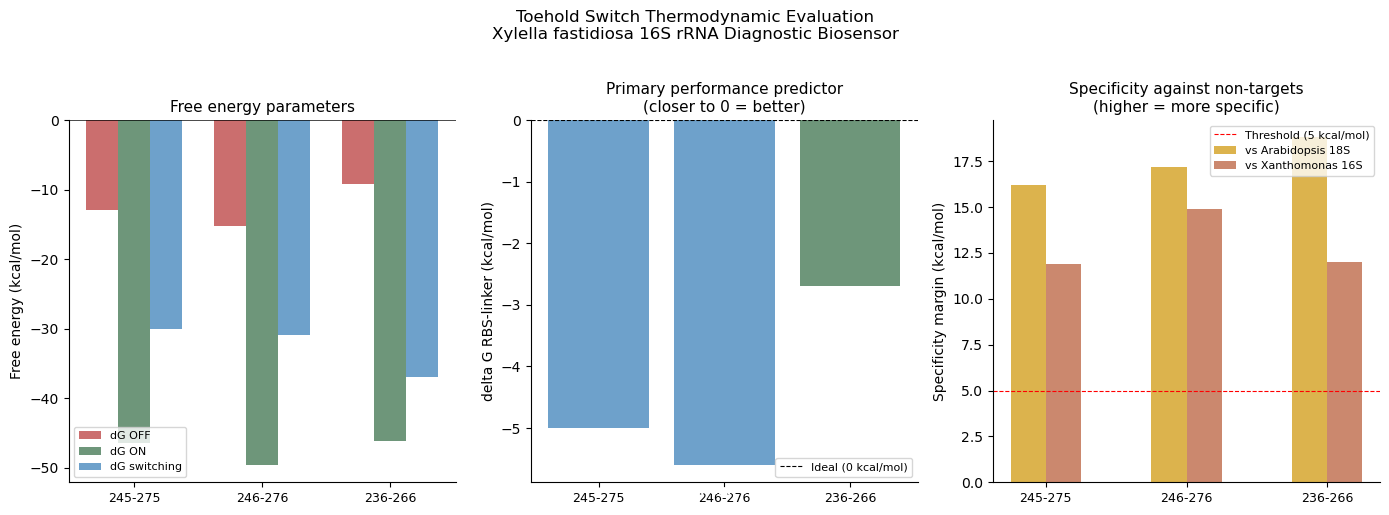

Evaluation plot saved to /home/andre/xylella-toehold-biosensor/results/switch_evaluation.png


In [12]:
# Visualise thermodynamic parameters across all three designs

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

targets = [r["target_id"].replace("R4_", "") for r in thermo_results]
colors = ["#4a7c59", "#4a8abf", "#8a6abf"]

# Plot 1: delta G values comparison
ax1 = axes[0]
x = np.arange(len(targets))
width = 0.25

bars_off = ax1.bar(x - width, 
                    [r["dg_off"] for r in thermo_results],
                    width, label="dG OFF", color="#bf4a4a", alpha=0.8)
bars_on = ax1.bar(x, 
                   [r["dg_on"] for r in thermo_results],
                   width, label="dG ON", color="#4a7c59", alpha=0.8)
bars_sw = ax1.bar(x + width,
                   [r["dg_switching"] for r in thermo_results],
                   width, label="dG switching", color="#4a8abf", alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(targets, fontsize=9)
ax1.set_ylabel("Free energy (kcal/mol)", fontsize=10)
ax1.set_title("Free energy parameters", fontsize=11)
ax1.legend(fontsize=8)
ax1.axhline(y=0, color="black", linewidth=0.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Plot 2: delta G RBS-linker (primary performance predictor)
ax2 = axes[1]
rbs_values = [r["dg_rbs_linker"] for r in thermo_results]
bars = ax2.bar(targets, rbs_values,
               color=["#4a7c59" if v == max(rbs_values) 
                      else "#4a8abf" for v in rbs_values],
               alpha=0.8)
ax2.axhline(y=0, color="black", linewidth=0.8, linestyle="--",
            label="Ideal (0 kcal/mol)")
ax2.set_ylabel("delta G RBS-linker (kcal/mol)", fontsize=10)
ax2.set_title("Primary performance predictor\n(closer to 0 = better)", 
              fontsize=11)
ax2.set_xticklabels(targets, fontsize=9)
ax2.legend(fontsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Add rank labels
for i, (bar, val) in enumerate(zip(bars, rbs_values)):
    rank = final_df[final_df["dg_rbs_linker"] == val]["rank"].values[0]
    ax2.text(bar.get_x() + bar.get_width()/2, val - 0.3,
             f"Rank {rank}", ha="center", va="top", fontsize=9,
             fontweight="bold", color="white")

# Plot 3: Specificity margins
ax3 = axes[2]
arab_margins = [r["specificity_margin"] for r in specificity_results
                if r["non_target"] == "Arabidopsis_18S"]
xanth_margins = [r["specificity_margin"] for r in specificity_results
                 if r["non_target"] == "Xanthomonas_16S"]

x = np.arange(len(targets))
ax3.bar(x - width/2, arab_margins, width,
        label="vs Arabidopsis 18S", color="#d4a020", alpha=0.8)
ax3.bar(x + width/2, xanth_margins, width,
        label="vs Xanthomonas 16S", color="#bf6a4a", alpha=0.8)
ax3.axhline(y=5, color="red", linewidth=0.8, linestyle="--",
            label="Threshold (5 kcal/mol)")
ax3.set_xticks(x)
ax3.set_xticklabels(targets, fontsize=9)
ax3.set_ylabel("Specificity margin (kcal/mol)", fontsize=10)
ax3.set_title("Specificity against non-targets\n(higher = more specific)",
              fontsize=11)
ax3.legend(fontsize=8)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.suptitle(
    "Toehold Switch Thermodynamic Evaluation\n"
    "Xylella fastidiosa 16S rRNA Diagnostic Biosensor",
    fontsize=12, y=1.02
)

plt.tight_layout()

plot_path = os.path.join(results_dir, "switch_evaluation.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Evaluation plot saved to {plot_path}")

## 7. Summary and next steps

Notebook 03 has completed the following.

1. Loaded three primary R4 candidate target sequences confirmed as 
   cross-strain accessible in notebook 02 and defined all toehold switch 
   design parameters following Green et al. (2014) second-generation rules.

2. Designed three toehold switch RNA sequences, each 80 nucleotides, using 
   a programmatic assembly algorithm implementing the five-component switch 
   architecture: toehold domain, left stem, loop with RBS, AUG start codon, 
   right stem, and linker.

3. Evaluated all three designs thermodynamically using ViennaRNA, calculating 
   delta G OFF, delta G ON, delta G switching, and delta G RBS-linker for 
   each design.

4. Screened all three designs for specificity against Arabidopsis thaliana 
   18S rRNA (NR_141642.1) and Xanthomonas campestris 16S rRNA (NR_119219.1), 
   with all six checks passing at margins substantially above the 5 kcal/mol 
   threshold.

5. Produced a final ranked table with R4_236-266 as the primary recommended 
   design based on the best delta G RBS-linker (-2.70 kcal/mol) and strongest 
   switching thermodynamics (-37.00 kcal/mol).

Output files produced:
- results/switch_designs.csv: final ranked switch designs with all parameters
- results/switch_evaluation.png: thermodynamic profile visualisation

Primary recommended design for experimental validation:
Trigger:  5'-GUGAAAUGCGUAGAGAUCAGGAGGAACAUC-3'
Switch:   5'-CCUGAUCUCUACGCAUUUCACGAUGUUCCUAAAAGAAGGAGATAAAAUGCUACAAGGAAACCCCTCAAGACCCGUUUGGC-3'

Recommended next steps before experimental synthesis:
1. Register for NUPACK academic access and implement automated switch 
   design to generate additional candidate sequences for the same target 
   sites, increasing the panel for experimental screening.
2. Extend toehold domain from 21nt to 24nt following accessibility 
   verification of the additional R4 alignment positions.
3. Perform full length cofold specificity screening against complete 
   Arabidopsis thaliana 18S rRNA and Xanthomonas campestris 16S rRNA 
   transcripts.
4. Validate experimentally in a cell-free expression system using the 
   LacZ colorimetric reporter following the protocol described by 
   Pardee et al. (2016).